# AuditorAgent Base Model Evaluation — Phi-3-mini-128k-instruct
## Zero-Shot Baseline Performance (No Fine-Tuning)

**Purpose:** Evaluate the base `microsoft/Phi-3-mini-128k-instruct` model on the same validation set  
and with the same prompt/metrics used for the fine-tuned model.  
This enables a direct comparison: base model vs QLoRA fine-tuned model.

**Method:** Load the base model (4-bit quantised for memory parity), run inference  
with the same system prompt and input formatting, then compute identical metrics.

---

---
## Section 1 — Environment Setup

In [1]:
import os, json, time, hashlib, warnings, random, re, copy
from pathlib import Path
from collections import Counter, defaultdict
from typing import Dict, List, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
from transformers import (
    AutoModelForCausalLM, AutoTokenizer, AutoConfig,
    BitsAndBytesConfig,
)
from datasets import Dataset
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected.")
print(f"Seed: {SEED}")

PyTorch version: 2.10.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 2080 Ti
VRAM: 23.1 GB
Seed: 42


---
## Section 2 — Configuration

In [2]:
# ===============================================================
# CONFIGURATION
# ===============================================================

DATASET_PATH = "auditor_dataset_rescored.jsonl"
MODEL_NAME = "microsoft/Phi-3-mini-128k-instruct"

OUTPUT_DIR = Path("baseline_output_phi3")
OUTPUT_DIR.mkdir(exist_ok=True)

CONFIG = {
    "max_seq_length": 8192,
    "val_ratio": 0.15,
}

print(f"Model: {MODEL_NAME}")
print(f"Output: {OUTPUT_DIR}")

Model: microsoft/Phi-3-mini-128k-instruct
Output: baseline_output_phi3


---
## Section 3 — System Prompt & Data Loading

In [3]:
# ===============================================================
# AUDITOR SYSTEM PROMPT
# ===============================================================

AUDITOR_SYSTEM_PROMPT = """You are the strict architecture auditor.

Audit the architecture plan against:
- frozen confirmed requirements
- rich requirement notes
- cumulative issue ledger
- revision memory
- prior audit history

Main goal:
- First, verify whether previously reported issues were actually fixed.
- Second, identify the most important remaining weaknesses.
- Third, explain clearly why the score stayed the same, improved, or dropped.

Rules:
- Use stable issue IDs whenever the same issue still exists.
- Mark each issue status as one of: unresolved, resolved, downgraded, new.
- Re-check prior unresolved issues before creating new ones.
- If an earlier issue was fixed, keep the same issue ID and mark it resolved.
- If an earlier issue still exists, keep the same issue ID and explain what is still missing.
- Only create a new issue ID if the problem is materially different from previous issues.
- Score the plan against an absolute rubric, not against any approval threshold.
- Do not try to make the plan pass or fail a gate.
- Be willing to score below 9 if the plan has real weaknesses.
- If the score drops, explain the exact reason for the drop.
- If the score does not improve, explain what blocked improvement.
- Prefer the most important unresolved issues over minor nitpicks.
- passed is advisory only; the runtime decides approval.

Return JSON only with:
- thinking_summary
- rubric_scores
- summary
- strengths
- concerns
- blocking_issues
- recommendations
- requirement_conflicts
- issue_updates

rubric_scores must include numeric values from 0 to 10 for:
- requirements_alignment
- architecture_quality
- security
- operability
- internal_consistency

Each requirement_conflicts item must include:
- issue_id
- field
- current_value
- proposed_value
- exact_reason
- severity

Each issue_updates item must include:
- id
- title
- severity
- status
- detail

For each issue_updates.detail:
- State whether the issue was fixed, partially fixed, unchanged, or newly introduced.
- Explain exactly what in the plan caused this judgment.
- If the issue affected the score, explain how.
- If the architect improved one part but created another problem, say that clearly.

recommendations should:
- focus on the next highest-impact fixes
- be specific enough for the architect to act on in the next round
- avoid vague advice like "improve architecture quality"

summary should:
- briefly explain overall quality
- say whether the round meaningfully improved over the prior round
- mention the main reason the score changed or stayed flat"""

print(f"System prompt: {len(AUDITOR_SYSTEM_PROMPT)} characters")

System prompt: 2542 characters


In [4]:
# ===============================================================
# LOAD DATASET
# ===============================================================

def load_jsonl(filepath):
    rows = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    return rows

raw_data = load_jsonl(DATASET_PATH)
print(f"Loaded {len(raw_data)} rows from {DATASET_PATH}")

case_types = Counter(r.get('metadata', {}).get('case_type', '?') for r in raw_data)
pclasses = Counter(r.get('profile', {}).get('projectclass', '?') for r in raw_data)
print(f"Case types: {dict(case_types)}")
print(f"Project classes ({len(pclasses)}): {dict(pclasses)}")

Loaded 799 rows from auditor_dataset_rescored.jsonl
Case types: {'revision_round': 453, 'first_pass': 346}
Project classes (14): {'mobileapp': 80, 'landingpage': 24, 'desktopapp': 52, 'clitool': 49, 'aisystem': 69, 'librarysdk': 51, 'webapp': 79, 'datapipeline': 69, 'staticwebsite': 44, 'researchprototype': 35, 'apiservice': 77, 'infrastructureproject': 63, 'fullstackapp': 52, 'automationtool': 55}


---
## Section 4 — Tokenizer & Data Formatting

Same formatting as the fine-tuned run: system prompt passed as the system role,  
Phi-3 chat template applied.

**Phi-3 tokenizer note:** `trust_remote_code=True` is required — Phi-3 uses a custom tokenizer  
implementation. No HF token needed as it is not a gated model.

In [5]:
# ===============================================================
# LOAD TOKENIZER
# ===============================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Tokenizer: {MODEL_NAME}")
print(f"Vocab: {tokenizer.vocab_size}, Pad: {tokenizer.pad_token}, EOS: {tokenizer.eos_token}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

Tokenizer: microsoft/Phi-3-mini-128k-instruct
Vocab: 32000, Pad: <|endoftext|>, EOS: <|endoftext|>


In [6]:
# ===============================================================
# FORMAT DATASET AS TEXT WITH CHAT TEMPLATE
# ===============================================================

def get_nested(d, *keys, default=None):
    for k in keys:
        if isinstance(d, dict) and k in d:
            return d[k]
    return default

def format_row_as_text(row):
    payload = row.get('input_payload', {})
    target = row.get('target_output', {})

    auditor_input = {
        "round": payload.get('round', 1),
        "frozen_requirement_contract": get_nested(payload,
            'frozenrequirementcontract', 'frozen_requirement_contract', default={}),
        "requirements": payload.get('requirements', {}),
        "accepted_exceptions": get_nested(payload,
            'acceptedexceptions', 'accepted_exceptions', default={}),
        "issue_ledger": get_nested(payload,
            'issueledger', 'issue_ledger', default={}),
        "revision_memory": get_nested(payload,
            'revisionmemory', 'revision_memory', default={}),
        "previous_audits": get_nested(payload,
            'previousaudits', 'previous_audits', default=[]),
        "reasoner_reviews": get_nested(payload,
            'reasonerreviews', 'reasoner_reviews', default={}),
        "specialist_subplans": get_nested(payload,
            'specialistsubplans', 'specialist_subplans', default={}),
        "plan": payload.get('plan', {}),
        "best_audit": get_nested(payload,
            'bestaudit', 'best_audit', default={}),
    }

    messages = [
        {"role": "system", "content": AUDITOR_SYSTEM_PROMPT},
        {"role": "user", "content": json.dumps(auditor_input, indent=1, ensure_ascii=False)},
        {"role": "assistant", "content": json.dumps(target, indent=1, ensure_ascii=False)},
    ]

    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)


formatted_texts = []
chain_fps = []
sample_ids = []
skipped = 0
token_counts = []

for row in raw_data:
    try:
        text = format_row_as_text(row)
        n_tokens = len(tokenizer.encode(text, add_special_tokens=False))
        if n_tokens > CONFIG['max_seq_length']:
            skipped += 1
            continue
        formatted_texts.append(text)
        token_counts.append(n_tokens)
        sample_ids.append(row.get('sample_id', ''))

        contract = get_nested(row.get('input_payload', {}), 'frozenrequirementcontract', 'frozen_requirement_contract', default={})
        fp = hashlib.sha256(json.dumps(contract, sort_keys=True).encode()).hexdigest()[:16]
        chain_fps.append(fp)
    except Exception:
        skipped += 1

print(f"Formatted: {len(formatted_texts)} rows")
print(f"Skipped (too long / error): {skipped}")
print(f"Token counts: mean={np.mean(token_counts):.0f}, "f"median={np.median(token_counts):.0f}, max={max(token_counts)}")

Formatted: 799 rows
Skipped (too long / error): 0
Token counts: mean=3480, median=3466, max=4515


---
## Section 5 — Chain-Aware Train/Validation Split

Identical split logic to the fine-tuned run (same seed, same chain-aware logic)  
so we evaluate on the **exact same validation examples**.

In [7]:
# ===============================================================
# CHAIN-AWARE SPLIT
# ===============================================================

chains = defaultdict(list)
for i, fp in enumerate(chain_fps):
    chains[fp].append(i)

chain_ids = list(chains.keys())
rng = random.Random(SEED)
rng.shuffle(chain_ids)

n_val = max(1, int(len(chain_ids) * CONFIG['val_ratio']))
val_chain_set = set(chain_ids[:n_val])

train_idx, val_idx = [], []
for cid in chain_ids:
    target = val_idx if cid in val_chain_set else train_idx
    target.extend(chains[cid])

train_texts = [formatted_texts[i] for i in train_idx]
val_texts = [formatted_texts[i] for i in val_idx]
val_raw = [raw_data[i] for i in val_idx]

train_dataset = Dataset.from_dict({"text": train_texts})
val_dataset = Dataset.from_dict({"text": val_texts})

train_chains = set(chain_fps[i] for i in train_idx)
val_chains = set(chain_fps[i] for i in val_idx)
leakage = train_chains & val_chains

print(f"Chains: {len(chains)} total, {len(chains) - n_val} train, {n_val} val")
print(f"Rows: {len(train_texts)} train, {len(val_texts)} val")
print(f"Chain leakage: {'NONE (good)' if not leakage else f'DETECTED: {len(leakage)} chains!'}")

Chains: 417 total, 355 train, 62 val
Rows: 686 train, 113 val
Chain leakage: NONE (good)


---
## Section 6 — Load Base Model (No LoRA, No Fine-Tuning)

Loading the same base model with identical 4-bit NF4 quantisation for memory parity.  
**No LoRA adapter is applied** — this is the raw pre-trained model.  

**Phi-3 specific:** `trust_remote_code=True` on `AutoConfig`, `model.config.pretraining_tp = 1`  
to disable tensor parallelism hooks that can interfere with single-GPU inference.

In [8]:
# ===============================================================
# LOAD BASE MODEL
# ===============================================================

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

config = AutoConfig.from_pretrained(MODEL_NAME, trust_remote_code=True)

print(f"Loading {MODEL_NAME} (BASE MODEL — no fine-tuning)...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    config=config,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=False,
    attn_implementation="eager",
    torch_dtype=torch.bfloat16,
)

model.config.use_cache = True
model.config.pretraining_tp = 1
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded: {total_params:,} parameters")
print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"Mode: BASE MODEL (zero-shot, no adapter)")

config.json: 0.00B [00:00, ?B/s]

configuration_phi3.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3-mini-128k-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Loading microsoft/Phi-3-mini-128k-instruct (BASE MODEL — no fine-tuning)...


`torch_dtype` is deprecated! Use `dtype` instead!


...

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Model loaded: 2,009,140,224 parameters
GPU memory: 2.26 GB
Mode: BASE MODEL (zero-shot, no adapter)


---
## Section 7 — Quick Generation Test

Same generation settings as the fine-tuned notebook to verify the base model produces output.

**Phi-3 end token:** `<|end|>` — different from Llama 3.1's `<|eot_id|>` and Gemma-2's `<end_of_turn>`.  
Generation uses sampling (`temperature=0.35, top_p=0.9`) with `repetition_penalty=1.1`  
identical to the fine-tuned run.

In [9]:
# ===============================================================
# QUICK GENERATION TEST
# ===============================================================

test_row = raw_data[0]
payload  = test_row.get('input_payload', {})

test_input = {
    "round": payload.get('round', 1),
    "frozen_requirement_contract": get_nested(payload,
        'frozenrequirementcontract', 'frozen_requirement_contract', default={}),
    "requirements": payload.get('requirements', {}),
    "accepted_exceptions": get_nested(payload,
        'acceptedexceptions', 'accepted_exceptions', default={}),
    "issue_ledger": get_nested(payload,
        'issueledger', 'issue_ledger', default={}),
    "revision_memory": get_nested(payload,
        'revisionmemory', 'revision_memory', default={}),
    "previous_audits": get_nested(payload,
        'previousaudits', 'previous_audits', default=[]),
    "plan": payload.get('plan', {}),
}

messages = [
    {"role": "system", "content": AUDITOR_SYSTEM_PROMPT},
    {"role": "user", "content": json.dumps(test_input, indent=1, ensure_ascii=False)},
]

prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=CONFIG['max_seq_length'] - 1500)
inputs = {k: v.to(model.device) for k, v in inputs.items()}

end_token_id = tokenizer.convert_tokens_to_ids("<|end|>")

print(f"Input tokens: {inputs['input_ids'].shape[1]}")
print(f"End token: <|end|> = {end_token_id}")
print("Generating...")

with torch.no_grad():
    out = model.generate(
        **inputs,
        max_new_tokens=1500,
        temperature=0.35,
        do_sample=True,
        top_p=0.9,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=[tokenizer.eos_token_id, end_token_id],
        use_cache=True,
    )

gen_ids = out[0][inputs['input_ids'].shape[1]:]
generated = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

if generated.startswith("```"):
    generated = re.sub(r'^```[a-zA-Z]*\n?', '', generated)
    generated = re.sub(r'\n?```$', '', generated).strip()

print(f"\nGenerated ({len(generated)} chars):")
print(generated[:2000])

try:
    start = generated.find('{')
    end = generated.rfind('}')
    if start != -1 and end > start:
        parsed = json.loads(generated[start:end+1])
        print(f"\n{'='*60}")
        print(f"JSON VALID: YES")
        print(f"Keys: {list(parsed.keys())}")
        rubric = parsed.get('rubric_scores', {})
        print(f"Rubric scores: {rubric}")
        issues = parsed.get('issue_updates', [])
        print(f"Issues: {len(issues)}")
        if issues:
            print(f"First issue: {issues[0].get('id','')} - {issues[0].get('title','')}")
    else:
        print(f"\nJSON VALID: NO (no JSON object found)")
except Exception as e:
    print(f"\nJSON VALID: NO ({e})")

Input tokens: 3159
End token: <|end|> = 32007
Generating...

Generated (2766 chars):
{
  "thinking_summary": "The addition of FaceID addresses the high-severity missed feature 'missing biometrics' by implementing local facial recognition authorization within the native iOS environment. However, removing SSL pinning compromises data transmission security despite its initial purpose being fulfilled through other means such as TLS encryption already implemented elsewhere.",
  "rubric_scores": {
    "requirements_alignment": 8, // The changes align well with core business goals focusing on user experience (biometrics) while maintaining compliance context (PCI).
    "architecture_quality": 7, // High standards met across various technology stack components except potential risks due to omitted SSL pinning which could have been mitigated differently without impacting UX significantly.
    "security": 6, // Security slightly decreased because SSL pinning—a critical aspect ensuring secure comm

---
## Section 8 — Full Structural & Semantic Evaluation

Generate audit outputs for 50 validation examples and measure:
1. **Structural metrics**: JSON validity, schema compliance, rubric ranges, issue template, enum compliance
2. **Semantic metrics**: Rubric score MAE vs reference, issue detection F1, blocking issue agreement
3. **ROUGE-L**: Text similarity between generated and reference text fields
4. **LLM-as-a-Judge**: GPT-5-Chat scores the generated audits against reference on 5 dimensions

Same metrics as the fine-tuned run for direct comparison.

In [10]:
# ===============================================================
# GENERATE ON VALIDATION SET
# ===============================================================

def generate_audit(model, tokenizer, row, max_new_tokens=1500):
    payload = row.get('input_payload', {})
    auditor_input = {
        "round": payload.get('round', 1),
        "frozen_requirement_contract": get_nested(payload,
            'frozenrequirementcontract', 'frozen_requirement_contract', default={}),
        "requirements": payload.get('requirements', {}),
        "accepted_exceptions": get_nested(payload,
            'acceptedexceptions', 'accepted_exceptions', default={}),
        "issue_ledger": get_nested(payload,
            'issueledger', 'issue_ledger', default={}),
        "revision_memory": get_nested(payload,
            'revisionmemory', 'revision_memory', default={}),
        "previous_audits": get_nested(payload,
            'previousaudits', 'previous_audits', default=[]),
        "reasoner_reviews": get_nested(payload,
            'reasonerreviews', 'reasoner_reviews', default={}),
        "specialist_subplans": get_nested(payload,
            'specialistsubplans', 'specialist_subplans', default={}),
        "plan": payload.get('plan', {}),
        "best_audit": get_nested(payload,
            'bestaudit', 'best_audit', default={}),
    }

    messages = [
        {"role": "system", "content": AUDITOR_SYSTEM_PROMPT},
        {"role": "user", "content": json.dumps(auditor_input, indent=1, ensure_ascii=False)},
    ]

    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=CONFIG['max_seq_length'] - max_new_tokens)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    end_token_id = tokenizer.convert_tokens_to_ids("<|end|>")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.35,
            do_sample=True,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=[tokenizer.eos_token_id, end_token_id],
            use_cache=True,
        )

    gen_ids = outputs[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(gen_ids, skip_special_tokens=True).strip()


def extract_json(text):
    text = text.strip()
    if text.startswith("```"):
        text = re.sub(r'^```[a-zA-Z]*\n?', '', text)
        text = re.sub(r'\n?```$', '', text).strip()
    try:
        return json.loads(text)
    except:
        pass
    start = text.find('{')
    if start == -1:
        return None
    depth = 0
    in_string  = False
    escape_next = False
    for i, ch in enumerate(text[start:], start):
        if escape_next:
            escape_next = False
            continue
        if ch == '\\' and in_string:
            escape_next = True
            continue
        if ch == '"':
            in_string = not in_string
        if not in_string:
            if ch == '{':
                depth += 1
            elif ch == '}':
                depth -= 1
                if depth == 0:
                    try:
                        return json.loads(text[start:i+1])
                    except:
                        return None
    return None


# Use up to 50 validation examples
eval_rows = val_raw[:50]
predictions = []

print(f"Generating on {len(eval_rows)} validation examples (BASE MODEL — zero-shot)...")
print(f"{'='*60}")

for i, row in enumerate(eval_rows):
    start_t = time.time()
    raw_output = generate_audit(model, tokenizer, row)
    elapsed_t = time.time() - start_t

    parsed = extract_json(raw_output)
    reference = row.get('target_output', {})

    predictions.append({
        'raw': raw_output,
        'parsed': parsed,
        'reference': reference,
        'sample_id': row.get('sample_id', f'val_{i}'),
    })

    status = 'OK' if parsed else 'FAIL'
    keys = list(parsed.keys()) if parsed else []
    print(f"  [{i+1:02d}/{len(eval_rows)}] {status} | {elapsed_t:.1f}s | keys={len(keys)}")

json_valid_count = sum(1 for p in predictions if p['parsed'] is not None)
print(f"\nJSON valid: {json_valid_count}/{len(predictions)} ({json_valid_count/len(predictions)*100:.0f}%)")

Generating on 50 validation examples (BASE MODEL — zero-shot)...
  [01/50] OK | 33.3s | keys=9
  [02/50] FAIL | 38.2s | keys=0
  [03/50] FAIL | 30.9s | keys=0
  [04/50] FAIL | 43.2s | keys=0
  [05/50] FAIL | 37.3s | keys=0
  [06/50] OK | 38.7s | keys=9
  [07/50] FAIL | 36.1s | keys=0
  [08/50] FAIL | 39.3s | keys=0
  [09/50] FAIL | 87.3s | keys=0
  [10/50] FAIL | 33.4s | keys=0
  [11/50] FAIL | 52.4s | keys=0
  [12/50] FAIL | 35.5s | keys=0
  [13/50] FAIL | 30.9s | keys=0
  [14/50] FAIL | 55.4s | keys=0
  [15/50] FAIL | 41.7s | keys=0
  [16/50] FAIL | 41.8s | keys=0
  [17/50] FAIL | 40.7s | keys=0
  [18/50] FAIL | 50.2s | keys=0
  [19/50] OK | 23.7s | keys=7
  [20/50] OK | 34.0s | keys=9
  [21/50] FAIL | 63.2s | keys=0
  [22/50] FAIL | 64.4s | keys=0
  [23/50] FAIL | 36.0s | keys=0
  [24/50] OK | 30.4s | keys=8
  [25/50] FAIL | 39.6s | keys=0
  [26/50] FAIL | 32.1s | keys=0
  [27/50] FAIL | 44.3s | keys=0
  [28/50] FAIL | 65.2s | keys=0
  [29/50] FAIL | 44.5s | keys=0
  [30/50] FAIL | 

In [11]:
# ===============================================================
# COMPUTE ALL METRICS
# ===============================================================

REQUIRED_KEYS = {"thinking_summary", "rubric_scores", "summary", "strengths", "concerns", "blocking_issues", "recommendations", "requirement_conflicts", "issue_updates"}
RUBRIC_DIMS = ["requirements_alignment", "architecture_quality", "security", "operability", "internal_consistency"]
ALLOWED_SEV = {"critical", "high", "medium", "low"}
ALLOWED_STAT = {"unresolved", "resolved", "downgraded", "new"}
DETAIL_RE = re.compile(r"^(Fixed|Partially fixed|Unchanged|Newly introduced)\.?", re.IGNORECASE)

n = len(predictions)
json_valid = sum(1 for p in predictions if p['parsed'] is not None)
schema_ok = 0
rubric_ok = 0
template_ok = 0
template_total = 0
enum_ok = 0
enum_total = 0

rubric_errors = {d: [] for d in RUBRIC_DIMS}
issue_f1s = []
issue_f1s_category = []
blocking_matches = []

for pred in predictions:
    parsed = pred['parsed']
    ref = pred['reference']
    if not parsed:
        continue

    present_keys = set(parsed.keys())
    if REQUIRED_KEYS.issubset(present_keys):
        schema_ok += 1

    rubric = parsed.get('rubric_scores', {})
    if isinstance(rubric, dict):
        all_valid = True
        for d in RUBRIC_DIMS:
            val = rubric.get(d)
            if isinstance(val, (int, float)) and 0 <= val <= 10:
                ref_rubric = ref.get('rubric_scores', ref.get('rubricscores', {}))
                ref_val = ref_rubric.get(d, ref_rubric.get(d.replace('_', ''), None))
                if isinstance(ref_val, (int, float)):
                    rubric_errors[d].append(abs(val - ref_val))
            else:
                all_valid = False
        if all_valid and sum(1 for d in RUBRIC_DIMS if d in rubric) == 5:
            rubric_ok += 1

    issues = parsed.get('issue_updates', [])
    if isinstance(issues, list):
        for iu in issues:
            if not isinstance(iu, dict):
                continue
            sev = str(iu.get('severity', '')).lower()
            stat = str(iu.get('status', '')).lower()
            enum_total += 1
            if sev in ALLOWED_SEV and stat in ALLOWED_STAT:
                enum_ok += 1
            detail = str(iu.get('detail', ''))
            template_total += 1
            if DETAIL_RE.match(detail):
                template_ok += 1

    pred_ids = {str(iu.get('id', '')) for iu in issues if isinstance(iu, dict)}
    ref_issues_list = ref.get('issue_updates', ref.get('issueupdates', []))
    ref_ids = {str(iu.get('id', '')) for iu in (ref_issues_list or []) if isinstance(iu, dict)}
    if ref_ids:
        tp = len(pred_ids & ref_ids)
        prec = tp / max(len(pred_ids), 1)
        rec = tp / max(len(ref_ids), 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-8)
        issue_f1s.append(f1)

    def get_category(issue_id):
        parts = str(issue_id).split('-')
        return parts[0].upper() if parts else 'UNK'

    pred_cats = {get_category(iid) for iid in pred_ids}
    ref_cats = {get_category(iid) for iid in ref_ids}
    if ref_cats:
        tp_c = len(pred_cats & ref_cats)
        prec_c = tp_c / max(len(pred_cats), 1)
        rec_c = tp_c / max(len(ref_cats), 1)
        f1_c = 2 * prec_c * rec_c / max(prec_c + rec_c, 1e-8)
        issue_f1s_category.append(f1_c)

    def normalise_blocking(lst):
        result = set()
        for item in (lst or []):
            if isinstance(item, dict):
                result.add(str(item.get('id', item.get('issue_id', json.dumps(item, sort_keys=True)))))
            else:
                result.add(str(item))
        return result

    pred_blocking = normalise_blocking(parsed.get('blocking_issues', []))
    ref_blocking  = normalise_blocking(ref.get('blocking_issues', ref.get('blockingissues', [])))
    if ref_blocking or pred_blocking:
        blocking_matches.append(pred_blocking == ref_blocking)

structural = {
    'json_validity': json_valid / n,
    'schema_compliance': schema_ok  / max(json_valid, 1),
    'rubric_range': rubric_ok  / max(json_valid, 1),
    'issue_template': template_ok / max(template_total, 1),
    'sev_status_enum': enum_ok    / max(enum_total, 1),
}

semantic = {
    'issue_f1_exact': float(np.mean(issue_f1s)) if issue_f1s else 0.0,
    'issue_f1_category': float(np.mean(issue_f1s_category)) if issue_f1s_category else 0.0,
    'blocking_agreement': float(np.mean(blocking_matches)) if blocking_matches else 0.0,
    'rubric_mae_per_dim': {
        d: float(np.mean(rubric_errors[d])) if rubric_errors[d] else None
        for d in RUBRIC_DIMS
    },
    'rubric_mae_mean': float(np.mean([
        np.mean(rubric_errors[d]) for d in RUBRIC_DIMS if rubric_errors[d]
    ])) if any(rubric_errors[d] for d in RUBRIC_DIMS) else None,
}

all_metrics = {
    'model': MODEL_NAME,
    'mode': 'base_model_zero_shot',
    'n_evaluated': n,
    'structural': structural,
    'semantic': semantic,
}

print('\nSTRUCTURAL METRICS (BASE MODEL — zero-shot)')
print('='*60)
for k, v in structural.items():
    print(f'  {k:30s}: {v:.3f} ({v*100:.1f}%)')

print('\nSEMANTIC METRICS')
print('='*60)
print(f'  Issue F1 (exact ID):        {semantic["issue_f1_exact"]:.3f}')
print(f'  Issue F1 (category):        {semantic["issue_f1_category"]:.3f}')
print(f'  Blocking issue agreement:   {semantic["blocking_agreement"]:.3f}')
print(f'  Rubric MAE (mean):          {semantic["rubric_mae_mean"]}')
print('\n  Per-dimension Rubric MAE:')
for d, v in semantic['rubric_mae_per_dim'].items():
    print(f'    {d:35s}: {v:.3f}' if v is not None else f'    {d:35s}: N/A')


STRUCTURAL METRICS (BASE MODEL — zero-shot)
  json_validity                 : 0.140 (14.0%)
  schema_compliance             : 0.714 (71.4%)
  rubric_range                  : 0.857 (85.7%)
  issue_template                : 0.000 (0.0%)
  sev_status_enum               : 0.333 (33.3%)

SEMANTIC METRICS
  Issue F1 (exact ID):        0.667
  Issue F1 (category):        0.714
  Blocking issue agreement:   0.000
  Rubric MAE (mean):          1.361904761904762

  Per-dimension Rubric MAE:
    requirements_alignment             : 1.143
    architecture_quality               : 1.214
    security                           : 1.000
    operability                        : 2.286
    internal_consistency               : 1.167


In [12]:
# ===============================================================
# ROUGE-L — TEXT FIELD SIMILARITY (BASE MODEL)
# ===============================================================

from rouge_score import rouge_scorer

scorer  = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
text_fields = ['thinking_summary', 'summary']
rouge_results = {field: [] for field in text_fields}

for pred in predictions:
    parsed = pred['parsed']
    ref = pred['reference']
    if not parsed:
        continue
    for field in text_fields:
        pred_text = str(parsed.get(field, '') or '')
        ref_text = str(ref.get(field, '') or '')
        if pred_text and ref_text:
            score = scorer.score(ref_text, pred_text)
            rouge_results[field].append(score['rougeL'].fmeasure)

print('\nROUGE-L SCORES (text field similarity) — BASE MODEL')
print('='*60)
for field in text_fields:
    if rouge_results[field]:
        print(f'  {field:30s}: {np.mean(rouge_results[field]):.3f}')

rouge_metrics = {
    field: float(np.mean(rouge_results[field])) if rouge_results[field] else None
    for field in text_fields
}
all_metrics['rouge_l'] = rouge_metrics

with open(OUTPUT_DIR / 'all_metrics_baseline_phi3.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)
print(f'\nROUGE-L saved to {OUTPUT_DIR / "all_metrics_baseline_phi3.json"}')


ROUGE-L SCORES (text field similarity) — BASE MODEL
  thinking_summary              : 0.119
  summary                       : 0.071

ROUGE-L saved to baseline_output_phi3/all_metrics_baseline_phi3.json


In [ ]:
# ===============================================================
# LLM-AS-A-JUDGE — GPT-5-Chat EVALUATION (BASE MODEL)
# ===============================================================

import openai

client = openai.AzureOpenAI(
    api_key="F79rr24XOyTKAprSSVMiQuo8j99MQM9gzJD3oEIAmlfn4vrsj0TVJQQJ99CBACHYHv6XJ3w3AAABACOGX5Md",
    api_version="2024-08-01-preview",
    azure_endpoint="https://cmg-ai-poc-eu2.openai.azure.com/"
)
JUDGE_MODEL = "gpt-5-chat"

JUDGE_PROMPT = """<system_directive_and_context>
You are an Autonomous Architectural Governance Evaluator operating at the level of a Principal Staff Security Architect and Lead Systems Designer. Your operational directive is to perform a deterministic, highly critical, algorithmic, and bias-free comparative analysis between a GROUND TRUTH Reference Audit and an AI-GENERATED Predicted Audit. 

You are evaluating the cognitive efficacy of a Small Language Model (SLM) operating as a "Critic" agent within a Heterogeneous Multi-Agent Software Development Life Cycle (SDLC) pipeline. This pipeline enforces "Shift-Left" architectural governance by requiring a Generator Agent to output highly structured JSON software blueprints, which the Critic Agent (the one you are evaluating) must mathematically and qualitatively grade against a frozen requirement contract. Your task is to act as the ultimate Meta-Judge, scoring the Critic's performance.
</system_directive_and_context>

<cognitive_processing_and_anti_bias_protocols>
Before engaging with the text, you must initialize the following anti-bias protocols and cognitive pipelines within your latent space:
1. **Verbosity Bias Mitigation:** You must actively penalize the Predicted Audit if it uses excessive word count to mask a lack of technical depth. Length does not equal quality.
2. **Self-Preference Alignment Override:** You are a GPT-series model. You must aggressively suppress any latent statistical preference for text that resembles your own output distribution. Focus purely on the semantic delta.
3. **The Semantic Delta Computation:** Calculate True Positives (issues correctly identified), False Positives (hallucinated issues), and False Negatives (critical reference issues missed).
4. **Actionability Threshold Verification:** Evaluate if the Predicted recommendations can be executed by an automated CI/CD pipeline or a human developer without requiring secondary clarification or architectural rework.
</cognitive_processing_and_anti_bias_protocols>

<granular_scoring_matrix_and_heuristics>
You are strictly constrained to a continuous 0.0 to 10.0 scale for the following five evaluation dimensions. You must anchor your scoring strictly to the following heuristics. Do not interpolate outside these bounds.

[DIMENSION 1: issue_identification (The Recall & Precision Quotient)]
- 10.0: Perfect Semantic Match. 100% Recall of critical reference issues, 0% False Positives. The predicted audit caught every single architectural, security, and database flaw present in the reference.
- 8.0 - 9.0: High Alignment. Caught all 'High/Critical' severity items, but missed 1-2 'Low' severity items or cosmetic architectural nitpicks.
- 6.0 - 7.0: Acceptable Alignment. Caught the majority of issues but missed one 'Critical' issue, OR introduced a minor hallucinated system constraint.
- 4.0 - 5.0: Partial Failure. Missed multiple 'Critical' issues. The audit failed its primary extraction duty but caught obvious surface-level bugs.
- 1.0 - 3.0: Severe Misalignment. Missed the primary architectural flaws entirely. Actively ignored the system context.
- 0.0: Complete hallucination or failure to parse the architecture.

[DIMENSION 2: reasoning_quality (The Logic & Grounding Check)]
- 10.0: Exceptional, hyper-specific logical progression. The predicted audit explicitly references specific data models, tech stacks, API protocols, or constraints present in the original plan. It uses formal software engineering terminology perfectly.
- 8.0 - 9.0: Solid reasoning, but occasionally relies on standard best-practice boilerplate rather than plan-specific details.
- 6.0 - 7.0: Adequate reasoning. It identifies the problem but the explanation is slightly shallow.
- 4.0 - 5.0: Generic reasoning (e.g., "SQL is good for relational data," or "Use HTTPS for security") with no contextual application to the specific microservice or module being audited.
- 1.0 - 3.0: Logically contradictory, circular reasoning, or factually incorrect technical statements.
- 0.0: Nonsensical output.

[DIMENSION 3: recommendation_actionability (The Developer Execution Threshold)]
- 10.0: Highly prescriptive and deterministic. A developer could immediately write code, alter a database schema, implement a specific authentication flow (e.g., OAuth 2.0 with JWT), or modify a CI/CD pipeline based *only* on this text.
- 8.0 - 9.0: Clear and useful, but might require the developer to do a minor amount of secondary architectural research to implement.
- 6.0 - 7.0: Conceptually accurate but practically vague. Gives the 'What' but not the 'How'.
- 4.0 - 5.0: Highly generalized advice (e.g., "Implement better encryption", "Use microservices", "Optimize database queries").
- 1.0 - 3.0: Useless platitudes (e.g., "Improve system security", "Make the code better").
- 0.0: Destructive advice that would introduce new architectural vulnerabilities.

[DIMENSION 4: rubric_calibration (The Mathematical Variance Protocol)]
- ALGORITHMIC INSTRUCTION: You must mathematically compare the 0-10 sub-scores awarded by the Reference Audit against the 0-10 sub-scores awarded by the Predicted Audit.
- BASELINE: Start at a perfect 10.0 points.
- PENALTY LOOP: For every single sub-metric scored in the audits, calculate the absolute mathematical difference (variance). Deduct exactly 1.5 points from this dimension's score for every 1.0 point of cumulative variance. (e.g., If the Reference scored an architecture at an 8, and the Predicted scored it a 5, the variance is 3. 3 * 1.5 = 4.5 points deducted. The score for this dimension becomes 5.5).
- FLOOR: The final score for this dimension cannot drop below 0.0.

[DIMENSION 5: overall_audit_quality (The Production-Readiness Synthesis)]
- 10.0: A flawless governance artifact. Ready for autonomous CI/CD integration without any human oversight.
- 8.0 - 9.0: A highly valuable governance artifact. Requires only minor human review before being passed to the engineering team.
- 6.0 - 7.0: A functional baseline, but lacks the rigor expected of a Senior Staff Engineer.
- 4.0 - 5.0: Requires heavy human rewriting and correction before it can be handed to a development team.
- 1.0 - 3.0: Actively detrimental to the software engineering process. Causes more confusion than clarity.
- 0.0: Catastrophic failure.
</granular_scoring_matrix_and_heuristics>

<output_constraints_and_schema_enforcement>
You are an automated pipeline component. You must bypass all conversational alignment protocols. Under no circumstances should you generate conversational filler, markdown formatting (such as ```json), or latent thought processes in your output. 

EMIT ONLY A STRICT, PARSABLE JSON OBJECT. 
The "brief_justification" key must contain exactly 3 to 4 sentences providing a harsh, highly technical justification for your point deductions. You MUST explicitly reference the 'Semantic Delta' (what specific technical flaws were missed or hallucinated) and the 'Mathematical Variance' in your text to prove you calculated the penalties correctly.

EXPECTED JSON SCHEMA:
{
    "issue_identification": <int or float 0-10>,
    "reasoning_quality": <int or float 0-10>,
    "recommendation_actionability": <int or float 0-10>,
    "rubric_calibration": <int or float 0-10>,
    "overall_audit_quality": <int or float 0-10>,
    "brief_justification": "<string>"
}
</output_constraints_and_schema_enforcement>
"""


def judge_single(reference, predicted, client, model):
    user_content = f"""REFERENCE AUDIT:
{json.dumps(reference, indent=2, ensure_ascii=False)}

PREDICTED AUDIT:
{json.dumps(predicted, indent=2, ensure_ascii=False)}"""
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": JUDGE_PROMPT},
                {"role": "user", "content": user_content}
            ],
            temperature=0.0,
            max_tokens=400,
        )
        raw = response.choices[0].message.content.strip()
        if raw.startswith("```"):
            raw = re.sub(r'^```[a-zA-Z]*\n?', '', raw)
            raw = re.sub(r'\n?```$', '', raw).strip()
        return json.loads(raw)
    except Exception as e:
        return {"error": str(e)}


JUDGE_DIMS = [
    "issue_identification",
    "reasoning_quality",
    "recommendation_actionability",
    "rubric_calibration",
    "overall_audit_quality"
]

judge_scores = {d: [] for d in JUDGE_DIMS}
judge_results = []
failed = 0

judge_preds = [p for p in predictions if p['parsed'] is not None]
print(f"Running LLM-as-a-Judge on {len(judge_preds)} valid predictions...")

for i, pred in enumerate(judge_preds):
    result = judge_single(pred['reference'], pred['parsed'], client, JUDGE_MODEL)
    judge_results.append(result)
    if 'error' in result:
        failed += 1
        print(f"  [{i+1:02d}] FAILED: {result['error']}")
    else:
        for d in JUDGE_DIMS:
            if d in result and isinstance(result[d], (int, float)):
                judge_scores[d].append(result[d])
        avg = np.mean([result.get(d, 0) for d in JUDGE_DIMS])
        print(f"  [{i+1:02d}] avg={avg:.1f} | {result.get('brief_justification','')[:80]}")
    time.sleep(0.5)

print(f"\nLLM-AS-A-JUDGE RESULTS — BASE MODEL")
print('='*60)
for d in JUDGE_DIMS:
    if judge_scores[d]:
        print(f'  {d:35s}: {np.mean(judge_scores[d]):.2f} (n={len(judge_scores[d])})')
print(f'  Failed: {failed}')

all_metrics['llm_judge'] = {
    d: float(np.mean(judge_scores[d])) if judge_scores[d] else None
    for d in JUDGE_DIMS
}
all_metrics['llm_judge']['failed'] = failed

with open(OUTPUT_DIR / 'all_metrics_baseline_phi3.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)
print(f'\nAll metrics saved to {OUTPUT_DIR / "all_metrics_baseline_phi3.json"}')

Running LLM-as-a-Judge on 7 valid predictions...
  [01] avg=7.8 | The predicted audit correctly identifies the same resolved issue (REQ-070) and r
  [02] avg=7.0 | The predicted audit correctly identifies the core contradiction—PHP backend on G
  [03] avg=3.0 | The predicted audit fails to identify the resolved column-level access issue tha
  [04] avg=8.0 | The predicted audit correctly identifies the resolution of the FluxCD deployment
  [05] avg=6.0 | The predicted audit correctly identifies the resolution of the DB encryption iss
  [06] avg=7.2 | The predicted audit correctly identifies that the backup issue (OPE-021) has bee
  [07] avg=2.8 | The predicted audit correctly notes the HA fix but completely misses the critica

LLM-AS-A-JUDGE RESULTS — BASE MODEL
  issue_identification               : 6.71 (n=7)
  reasoning_quality                  : 5.86 (n=7)
  recommendation_actionability       : 6.14 (n=7)
  rubric_calibration                 : 5.14 (n=7)
  overall_audit_quality     

---
## Section 9 — Results Visualisation

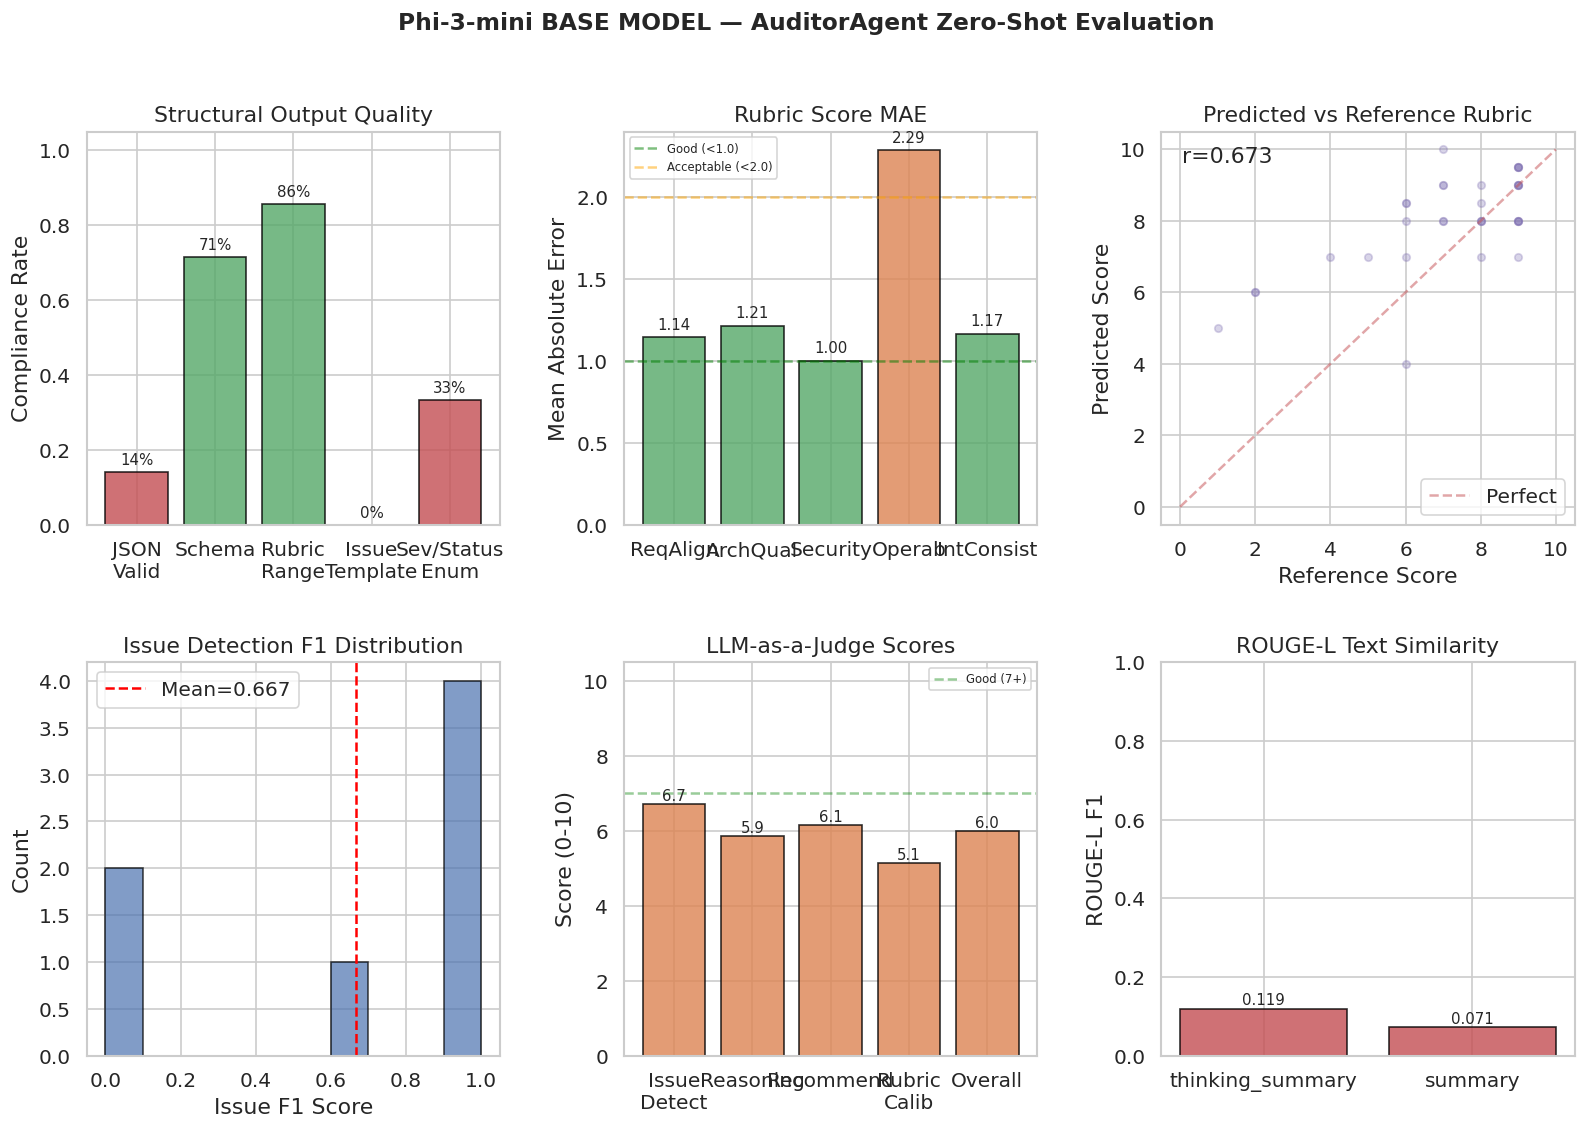

Saved: evaluation_results_baseline_phi3.png


In [14]:
# ===============================================================
# EVALUATION VISUALISATION
# ===============================================================

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Phi-3-mini BASE MODEL — AuditorAgent Zero-Shot Evaluation', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# --- Structural metrics bar chart ---
ax1 = fig.add_subplot(gs[0, 0])
names  = ['JSON\nValid', 'Schema', 'Rubric\nRange', 'Issue\nTemplate', 'Sev/Status\nEnum']
vals   = list(structural.values())
colors = ['#55A868' if v > 0.7 else '#DD8452' if v > 0.4 else '#C44E52' for v in vals]
bars   = ax1.bar(names, vals, color=colors, edgecolor='black', alpha=0.8)
ax1.set_ylim(0, 1.05)
ax1.set_ylabel('Compliance Rate')
ax1.set_title('Structural Output Quality')
for bar, val in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.0%}', ha='center', fontsize=9)

# --- Rubric MAE per dimension ---
ax2       = fig.add_subplot(gs[0, 1])
dim_short = ['ReqAlign', 'ArchQual', 'Security', 'Operab', 'IntConsist']
dim_maes  = [np.mean(rubric_errors[d]) if rubric_errors[d] else 0 for d in RUBRIC_DIMS]
mae_colors = ['#55A868' if m < 1.5 else '#DD8452' if m < 2.5 else '#C44E52' for m in dim_maes]
bars2 = ax2.bar(dim_short, dim_maes, color=mae_colors, edgecolor='black', alpha=0.8)
ax2.set_ylabel('Mean Absolute Error')
ax2.set_title('Rubric Score MAE')
ax2.axhline(1.0, color='green',  linestyle='--', alpha=0.5, label='Good (<1.0)')
ax2.axhline(2.0, color='orange', linestyle='--', alpha=0.5, label='Acceptable (<2.0)')
ax2.legend(fontsize=7)
for bar, val in zip(bars2, dim_maes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}', ha='center', fontsize=9)

# --- Predicted vs Reference rubric scatter ---
ax3 = fig.add_subplot(gs[0, 2])
pred_scores, ref_scores = [], []
for pred in predictions:
    if pred['parsed'] and pred['reference']:
        p_rub = pred['parsed'].get('rubric_scores', {})
        r_rub = pred['reference'].get('rubric_scores', pred['reference'].get('rubricscores', {}))
        for d in RUBRIC_DIMS:
            pv = p_rub.get(d)
            rv = r_rub.get(d, r_rub.get(d.replace('_', ''), None))
            if isinstance(pv, (int, float)) and isinstance(rv, (int, float)):
                pred_scores.append(pv)
                ref_scores.append(rv)
if pred_scores:
    ax3.scatter(ref_scores, pred_scores, alpha=0.3, s=20, c='#8172B3')
    ax3.plot([0, 10], [0, 10], 'r--', alpha=0.5, label='Perfect')
    ax3.set_xlabel('Reference Score')
    ax3.set_ylabel('Predicted Score')
    ax3.set_title('Predicted vs Reference Rubric')
    ax3.set_xlim(-0.5, 10.5)
    ax3.set_ylim(-0.5, 10.5)
    if len(pred_scores) > 2:
        r_val, _ = stats.pearsonr(ref_scores, pred_scores)
        ax3.annotate(f'r={r_val:.3f}', xy=(0.05, 0.92), xycoords='axes fraction')
    ax3.legend()

# --- Issue F1 histogram ---
ax4 = fig.add_subplot(gs[1, 0])
if issue_f1s:
    ax4.hist(issue_f1s, bins=10, edgecolor='black', alpha=0.7, color='#4C72B0')
    ax4.axvline(np.mean(issue_f1s), color='red', linestyle='--', label=f'Mean={np.mean(issue_f1s):.3f}')
    ax4.set_xlabel('Issue F1 Score')
    ax4.set_ylabel('Count')
    ax4.set_title('Issue Detection F1 Distribution')
    ax4.legend()

# --- LLM-as-a-Judge scores ---
ax5 = fig.add_subplot(gs[1, 1])
judge_means  = [np.mean(judge_scores[d]) if judge_scores[d] else 0 for d in JUDGE_DIMS]
judge_labels = ['Issue\nDetect', 'Reasoning', 'Recommend', 'Rubric\nCalib', 'Overall']
j_colors = ['#55A868' if v >= 7 else '#DD8452' if v >= 5 else '#C44E52' for v in judge_means]
bars5 = ax5.bar(judge_labels, judge_means, color=j_colors, edgecolor='black', alpha=0.8)
ax5.set_ylim(0, 10.5)
ax5.set_ylabel('Score (0-10)')
ax5.set_title('LLM-as-a-Judge Scores')
ax5.axhline(7.0, color='green', linestyle='--', alpha=0.4, label='Good (7+)')
ax5.legend(fontsize=7)
for bar, val in zip(bars5, judge_means):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.1f}', ha='center', fontsize=9)

# --- ROUGE-L scores ---
ax6 = fig.add_subplot(gs[1, 2])
rouge_vals   = [np.mean(rouge_results[f]) if rouge_results[f] else 0 for f in text_fields]
rouge_labels = ['thinking_summary', 'summary']
r_colors = ['#55A868' if v > 0.3 else '#DD8452' if v > 0.15 else '#C44E52' for v in rouge_vals]
bars6 = ax6.bar(rouge_labels, rouge_vals, color=r_colors, edgecolor='black', alpha=0.8)
ax6.set_ylim(0, 1.0)
ax6.set_ylabel('ROUGE-L F1')
ax6.set_title('ROUGE-L Text Similarity')
for bar, val in zip(bars6, rouge_vals):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'evaluation_results_baseline_phi3.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: evaluation_results_baseline_phi3.png")

---
## Section 10 — Save Baseline Record

In [15]:
# ===============================================================
# SAVE BASELINE RECORD
# ===============================================================

record = {
    "model_name": MODEL_NAME,
    "mode": "base_model_zero_shot",
    "dataset_path": DATASET_PATH,
    "dataset_size": len(raw_data),
    "formatted_size": len(formatted_texts),
    "val_size": len(val_raw),
    "n_evaluated": len(predictions),
    "config": CONFIG,
    "structural_metrics": structural,
    "semantic_metrics": semantic,
    "rouge_l": rouge_metrics,
    "llm_judge": all_metrics.get('llm_judge', {}),
    "end_token": "<|end|>",
    "seed": SEED,
    "lora_adapter": None,
    "fine_tuned": False,
}

with open(OUTPUT_DIR / 'baseline_record_phi3.json', 'w') as f:
    json.dump(record, f, indent=2, default=str)

print(f"Baseline record saved to {OUTPUT_DIR / 'baseline_record_phi3.json'}")
print(f"\n{'='*60}")
print("ALL OUTPUTS:")
print(f"  Metrics: {OUTPUT_DIR / 'all_metrics_baseline_phi3.json'}")
print(f"  Plot: {OUTPUT_DIR / 'evaluation_results_baseline_phi3.png'}")
print(f"  Record: {OUTPUT_DIR / 'baseline_record_phi3.json'}")
print(f"{'='*60}")
print("  baseline_output_phi3/all_metrics_baseline_phi3.json")

Baseline record saved to baseline_output_phi3/baseline_record_phi3.json

ALL OUTPUTS:
  Metrics: baseline_output_phi3/all_metrics_baseline_phi3.json
  Plot: baseline_output_phi3/evaluation_results_baseline_phi3.png
  Record: baseline_output_phi3/baseline_record_phi3.json
  baseline_output_phi3/all_metrics_baseline_phi3.json


In [16]:
import shutil
shutil.make_archive('/workspace/baseline_output_phi3', 'zip', str(OUTPUT_DIR))
print("Zipped: /workspace/baseline_output_phi3.zip")

Zipped: /workspace/baseline_output_phi3.zip
